# 01 — Análise Exploratória (EDA)
**Responsável**: P2 (Presencial)

**Objetivo**: Explorar os dados, gerar visualizações para slides, responder Guiding Questions C (mercado).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_parquet('../data/processed/artist_country_features.parquet')
print(f'Shape: {df.shape}')
df.head()

Shape: (13220, 19)


,artist_uri,country,artist_name,total_tracks,total_streams,avg_rank,best_rank,days_on_chart_total,first_entry_date,last_seen_date,entry_count,label_mode,stream_concentration,trend_30d,trend_90d,days_since_last_seen,monthly_listeners,peak_listeners,listener_ratio
0,spotify:artist:002HSjuWsGMinkXTa7JcRp,us,Turbo,1,246844.0,168.000000,168,1.0,2020-04-03,2020-04-03,1,"Turbo Publishing, LLC",1.000000,NaN,NaN,2246,1095203.0,2648992.0,0.413441
1,spotify:artist:004h2uqVUpmOuz4oY6aTqw,br,EME,2,2140197.0,151.031250,116,20.0,2018-06-03,2018-10-25,2,Sony Music Entertainment,0.576840,NaN,NaN,2772,NaN,NaN,NaN
2,spotify:artist:007FXgr0jLBJxhPJjacXQH,br,Eric Land,20,462289872.0,95.912000,1,387.0,2020-06-07,2026-02-08,16,Eric Land,0.223853,NaN,-1.0,109,4626448.0,7868161.0,0.587996
3,spotify:artist:00CEIWvwRzWGVahslNZW0Z,mx,Hernan Sepulveda,1,3713322.0,163.375000,114,16.0,2024-09-25,2024-10-17,1,Music VIP Entertainment Presenta Grupo Firme,1.000000,NaN,NaN,588,3013385.0,3729420.0,0.808004
4,spotify:artist:00CMSJdbf36zOzKB3z8JrR,ar,Victor Cardenas,1,9509263.0,107.858407,57,226.0,2019-08-04,2020-05-02,1,Sony Music México,1.000000,NaN,NaN,2217,1980721.0,3077394.0,0.643636


## 1. Visão Geral por País

  country  artistas_unicos  total_streams  avg_tracks_per_artist
0      ar             1919   1.004228e+11               6.652944
1      br             3300   3.134324e+11               5.444242
2      gb             3260   1.111940e+11               5.913190
3      mx             1899   2.682494e+11               5.921538
4      us             2842   4.357873e+11               7.858902


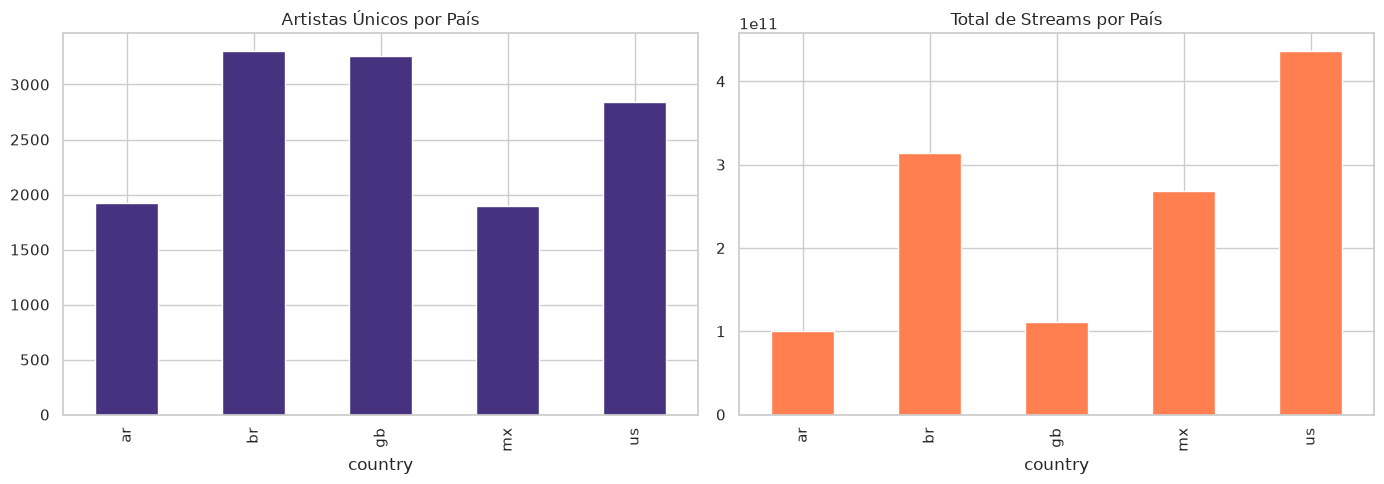

In [10]:
# Artistas únicos e total de streams por país
summary = df.groupby('country').agg(
    artistas_unicos=('artist_uri','nunique'),
    total_streams=('total_streams','sum'),
    avg_tracks_per_artist=('total_tracks','mean'),
).reset_index()
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
summary.plot.bar(x='country', y='artistas_unicos', ax=axes[0], title='Artistas Únicos por País', legend=False)
summary.plot.bar(x='country', y='total_streams', ax=axes[1], title='Total de Streams por País', legend=False, color='coral')
plt.tight_layout()
plt.savefig('../docs/eda_country_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Top 20 Artistas por País

In [11]:
for country in ['br', 'us', 'gb']:
    top20 = df[df['country']==country].nlargest(20, 'total_streams')
    print(f'\n=== TOP 20 — {country.upper()} ===')
    print(top20[['artist_name','total_streams','total_tracks','avg_rank','best_rank']].to_string(index=False))


=== TOP 20 — BR ===
        artist_name  total_streams  total_tracks   avg_rank  best_rank
 Henrique & Juliano   7213092084.0           212  97.819450          1
   Marília Mendonça   5288258020.0           171  86.426410          1
      Gusttavo Lima   4589980763.0           204  84.172691          1
Zé Neto & Cristiano   4529850056.0           125  84.609811          1
        Ana Castela   4431963484.0           100  79.898536          1
     Jorge & Mateus   4389974702.0           125  88.535220          1
         MC Ryan SP   4369128804.0           152  96.265565          1
    Matheus & Kauan   4113411240.0           142  84.419006          1
   Maiara & Maraisa   3016666044.0           121  82.980423          1
 Grupo Menos É Mais   2913391388.0            56  93.424321          1
             Anitta   2898102351.0           205  79.664340          1
     Wesley Safadão   2888513022.0           131  83.772516          1
   Hugo & Guilherme   2616552346.0            77  82.140

## 3. Análise de Labels (Gravadoras)


Top Labels — BR
label_mode
Som Livre                   4.109817e+10
Sony Music Entertainment    3.350784e+10
WM Brazil                   2.961031e+10
Universal Music Ltda.       2.029547e+10
GR6 Music                   1.683697e+10
Mainstreet Records          1.091353e+10
Pineapple StormTV           8.594996e+09
Love Funk                   7.830752e+09
Vida Nova Producoes         7.213092e+09
AgroPlay                    5.253903e+09
Sonar Music                 4.332703e+09
Supernova Entertainment     3.621782e+09
Elenko Music                3.323488e+09
Wesley Safadao              2.977540e+09
M Show                      2.492617e+09
Name: total_streams, dtype: float64


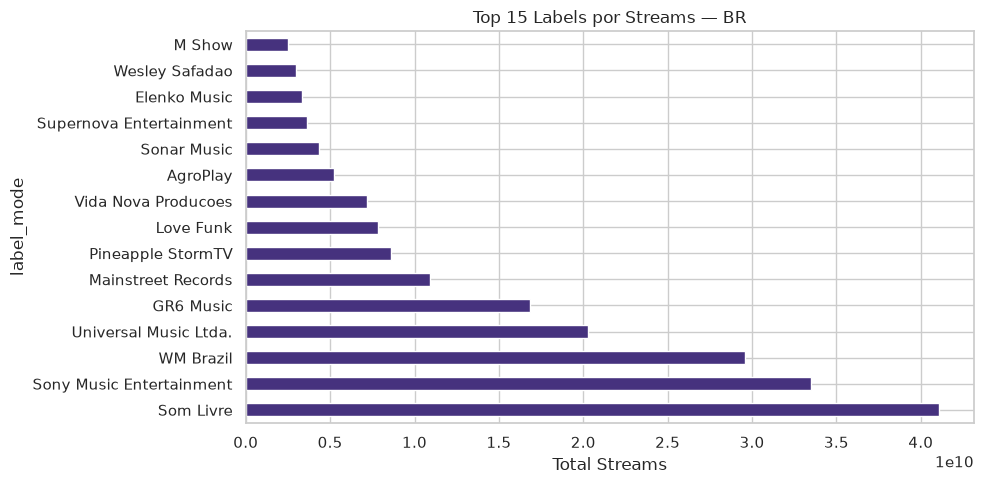


Top Labels — US
label_mode
Republic Records                                      2.607933e+10
Columbia                                              2.527864e+10
Warner Records                                        1.564229e+10
Cash Money Records/Young Money Ent./Universal Rec.    1.467849e+10
Atlantic Records                                      1.134226e+10
Taylor Swift                                          1.022237e+10
Morgan Wallen                                         9.942378e+09
Aftermath                                             9.246478e+09
Rimas Entertainment LLC                               8.282894e+09
K-Pop Demon Hunters                                   7.782269e+09
The Weeknd/Lyric                                      7.259248e+09
Cactus Jack / Epic                                    7.234804e+09
Generation Now/Atlantic                               6.544892e+09
Grade A Productions/Interscope Records                6.455906e+09
Darkroom/Interscope Records       

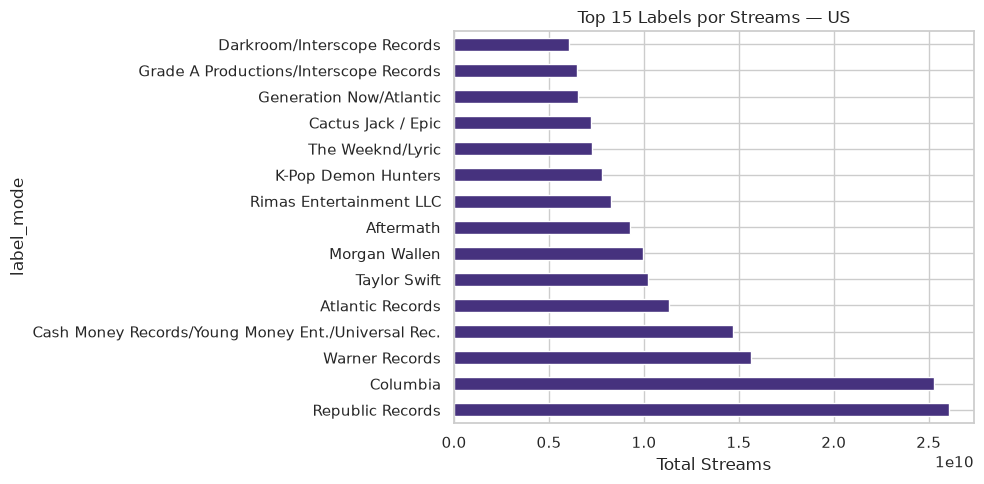

In [12]:
# Top labels por país
for country in ['br', 'us']:
    sub = df[df['country']==country]
    top_labels = sub.groupby('label_mode')['total_streams'].sum().nlargest(15)
    print(f'\nTop Labels — {country.upper()}')
    print(top_labels)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    top_labels.plot.barh(ax=ax, title=f'Top 15 Labels por Streams — {country.upper()}')
    ax.set_xlabel('Total Streams')
    plt.tight_layout()
    plt.savefig(f'../docs/eda_labels_{country}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Distribuição de Métricas-Chave

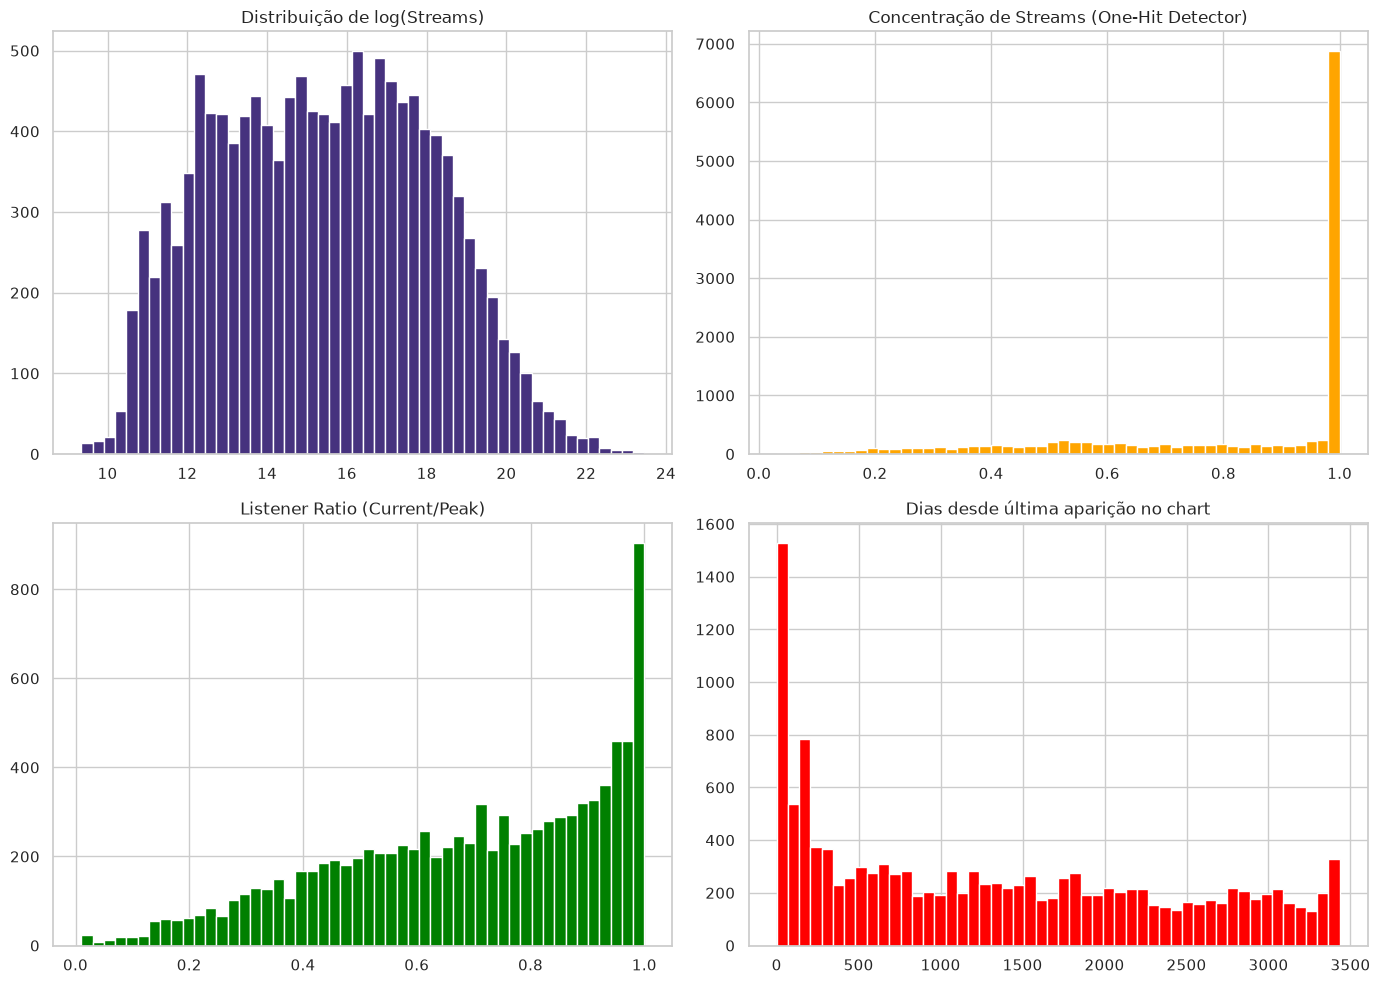

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['log_streams'] = np.log1p(df['total_streams'])
df['log_streams'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Distribuição de log(Streams)')

df['stream_concentration'].hist(bins=50, ax=axes[0,1], color='orange')
axes[0,1].set_title('Concentração de Streams (One-Hit Detector)')

df['listener_ratio'].dropna().hist(bins=50, ax=axes[1,0], color='green')
axes[1,0].set_title('Listener Ratio (Current/Peak)')

df['days_since_last_seen'].hist(bins=50, ax=axes[1,1], color='red')
axes[1,1].set_title('Dias desde última aparição no chart')

plt.tight_layout()
plt.savefig('../docs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análise Temporal / Sazonalidade
*(Requer o charts original — rodar se tiver RAM suficiente ou usar sample)*

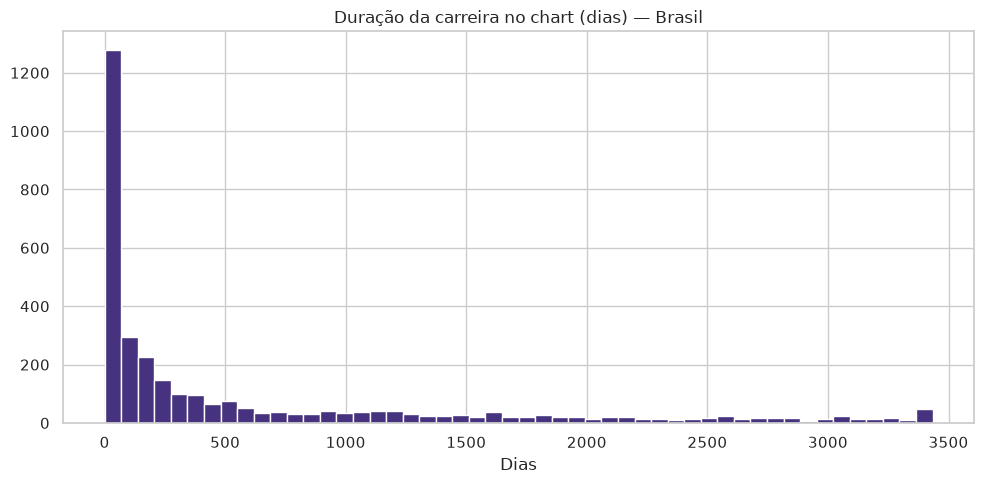

In [14]:
# Placeholder: se quiser análise temporal, carregar subset do charts
# df_charts_br = pd.read_csv('../charts_songs_daily.csv', chunksize=1_000_000)
# Por agora, análise temporal com first/last entry

df_br = df[df['country']=='br'].copy()
df_br['career_span_days'] = (df_br['last_seen_date'] - df_br['first_entry_date']).dt.days

fig, ax = plt.subplots(figsize=(10,5))
df_br['career_span_days'].hist(bins=50, ax=ax)
ax.set_title('Duração da carreira no chart (dias) — Brasil')
ax.set_xlabel('Dias')
plt.tight_layout()
plt.savefig('../docs/eda_career_span_br.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Artistas com mais de 3000 dias de carreira no chart (Brasil)

`career_span_days` = última aparição − primeira aparição no Top 200 do Brasil. A janela da base vai de **2017-01-01 a 2026-05-28 (3434 dias)**, então passar de 3000 dias (~8,2 anos) significa ter chartado de ponta a ponta, ou quase: veteranos do sertanejo, pop internacional recorrente e catálogo que não saiu do ranking.

Artistas BR: 3,300
Com carreira > 3000 dias: 130 (3.9%)
Ainda no chart no último dia da base: 55
Janela da base: 2017-01-01 → 2026-05-28 (3434 dias)

=== Artistas BR com carreira no chart > 3000 dias ===
              artist_name  career_span_days first_entry_date last_seen_date  total_tracks  total_streams  best_rank  days_since_last_seen
       Henrique & Juliano              3434       2017-01-01     2026-05-28           212   7213092084.0          1                     0
         Marília Mendonça              3434       2017-01-01     2026-05-28           171   5288258020.0          1                     0
            Gusttavo Lima              3434       2017-01-01     2026-05-28           204   4589980763.0          1                     0
      Zé Neto & Cristiano              3434       2017-01-01     2026-05-28           125   4529850056.0          1                     0
           Jorge & Mateus              3434       2017-01-01     2026-05-28           125   4389974702.0  

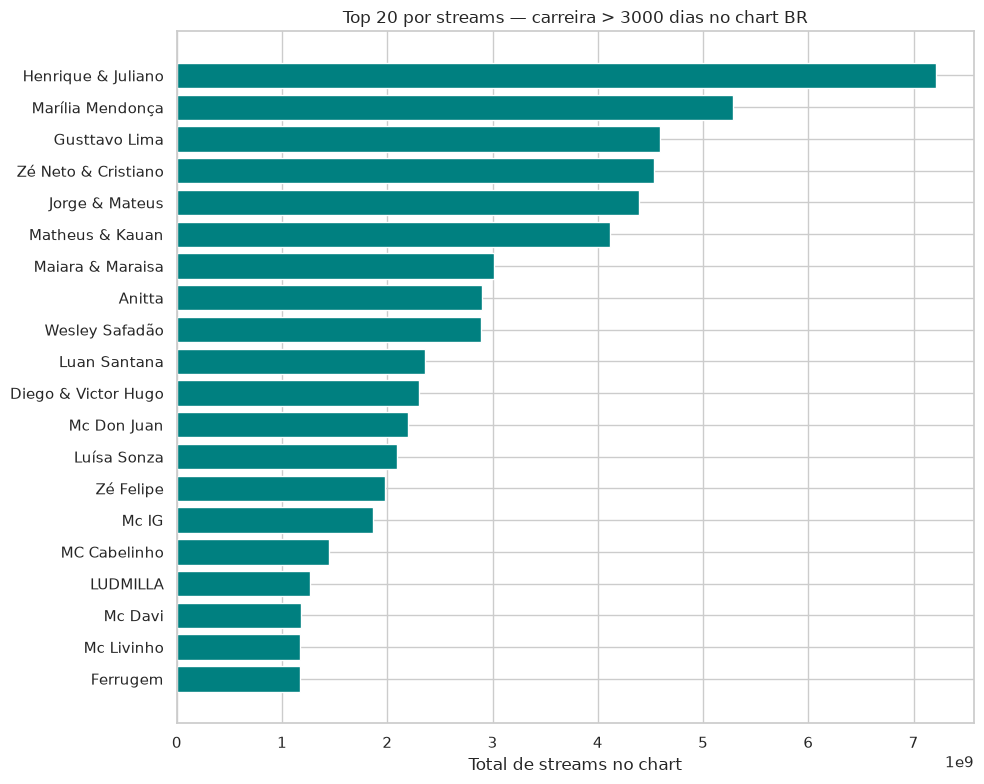

In [15]:
df_br = df[df['country']=='br'].copy()
df_br['career_span_days'] = (df_br['last_seen_date'] - df_br['first_entry_date']).dt.days

vets = (
    df_br[df_br['career_span_days'] > 3000]
    .sort_values(['career_span_days', 'total_streams'], ascending=False)
    .copy()
)
vets['artist_name'] = vets['artist_name'].fillna('Unknown')

print(f'Artistas BR: {len(df_br):,}')
print(f'Com carreira > 3000 dias: {len(vets):,} ({100*len(vets)/len(df_br):.1f}%)')
print(f'Ainda no chart no último dia da base: {(vets["days_since_last_seen"]==0).sum()}')
print(
    f'Janela da base: {df_br["first_entry_date"].min().date()} → '
    f'{df_br["last_seen_date"].max().date()} '
    f'({(df_br["last_seen_date"].max() - df_br["first_entry_date"].min()).days} dias)'
)

cols = [
    'artist_name', 'career_span_days', 'first_entry_date', 'last_seen_date',
    'total_tracks', 'total_streams', 'best_rank', 'days_since_last_seen',
]
print('\n=== Artistas BR com carreira no chart > 3000 dias ===')
print(vets[cols].to_string(index=False))

top = vets.nlargest(20, 'total_streams').iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top['artist_name'], top['total_streams'], color='teal')
ax.set_title('Top 20 por streams — carreira > 3000 dias no chart BR')
ax.set_xlabel('Total de streams no chart')
plt.tight_layout()
plt.savefig('../docs/eda_veterans_br.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlação entre Features

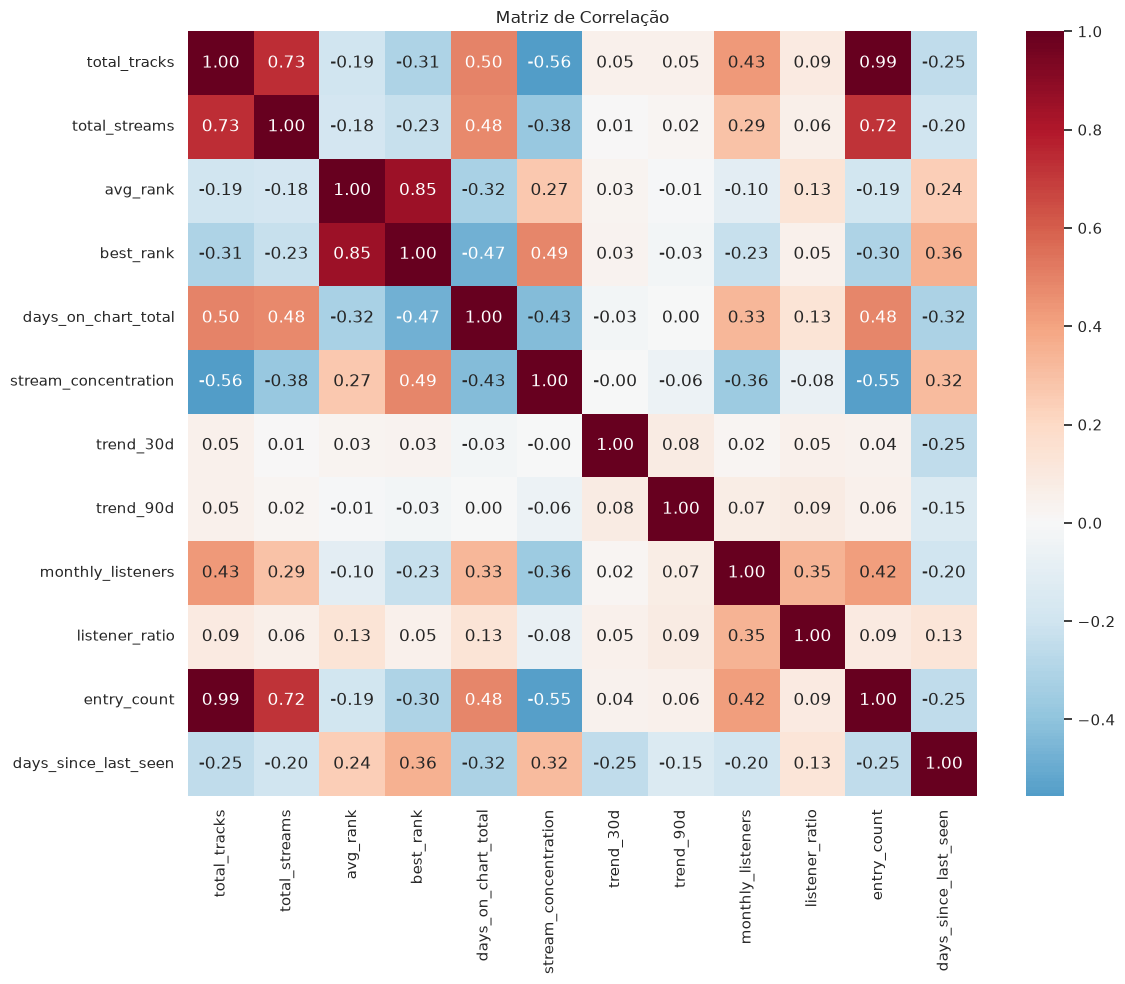

In [16]:
numeric_cols = ['total_tracks','total_streams','avg_rank','best_rank',
    'days_on_chart_total','stream_concentration','trend_30d','trend_90d',
    'monthly_listeners','listener_ratio','entry_count','days_since_last_seen']

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Matriz de Correlação')
plt.tight_layout()
plt.savefig('../docs/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()